# Comparing SVM Kernels (Linear, Polynomial, RBF) on Fashion MNIST

**Objective:** Implement and compare the performance of SVM classifiers with linear, polynomial, and RBF kernels on the Fashion MNIST dataset. Analyze the advantages and disadvantages of each kernel type.

**Tasks:**
1. Load and preprocess the Fashion MNIST dataset.
2. Implement SVM with linear, polynomial, and RBF kernels.
3. Compare the classification performance for each kernel.
4. Discuss the strengths and weaknesses of each kernel type.

## Task 1: Load and Preprocess the Fashion MNIST Dataset

Fashion MNIST consists of 70,000 grayscale 28x28 images across 10 clothing categories (60,000 train / 10,000 test). We download the original files directly from the official Zalando Research GitHub repository.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gzip
import os
import urllib.request
import time

from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

In [2]:
# Download the Fashion MNIST raw files (official Zalando Research repository)
DATA_DIR = 'fashion_mnist_data'
os.makedirs(DATA_DIR, exist_ok=True)

BASE_URL = 'https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/'
FILES = [
    'train-images-idx3-ubyte.gz',
    'train-labels-idx1-ubyte.gz',
    't10k-images-idx3-ubyte.gz',
    't10k-labels-idx1-ubyte.gz'
]

for fname in FILES:
    fpath = os.path.join(DATA_DIR, fname)
    if not os.path.exists(fpath):
        print(f'Downloading {fname} ...')
        urllib.request.urlretrieve(BASE_URL + fname, fpath)
    else:
        print(f'{fname} already exists, skipping download.')
print('Done.')

train-images-idx3-ubyte.gz already exists, skipping download.
train-labels-idx1-ubyte.gz already exists, skipping download.
t10k-images-idx3-ubyte.gz already exists, skipping download.
t10k-labels-idx1-ubyte.gz already exists, skipping download.
Done.


In [3]:
def load_images(path):
    """Load Fashion-MNIST image file into an (N, 784) uint8 array."""
    with gzip.open(path, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28 * 28)

def load_labels(path):
    """Load Fashion-MNIST label file into an (N,) uint8 array."""
    with gzip.open(path, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data

X_train_full = load_images(os.path.join(DATA_DIR, 'train-images-idx3-ubyte.gz'))
y_train_full = load_labels(os.path.join(DATA_DIR, 'train-labels-idx1-ubyte.gz'))
X_test_full  = load_images(os.path.join(DATA_DIR, 't10k-images-idx3-ubyte.gz'))
y_test_full  = load_labels(os.path.join(DATA_DIR, 't10k-labels-idx1-ubyte.gz'))

print('Full train set:', X_train_full.shape, y_train_full.shape)
print('Full test set: ', X_test_full.shape, y_test_full.shape)

Full train set: (60000, 784) (60000,)
Full test set:  (10000, 784) (10000,)


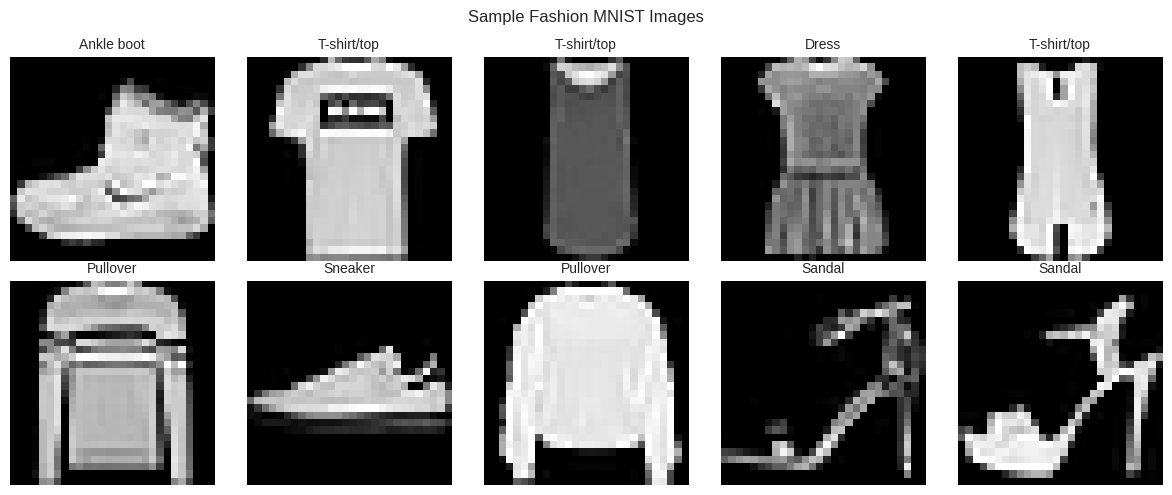

In [4]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Visualize a few sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_full[i].reshape(28, 28), cmap='gray')
    ax.set_title(class_names[y_train_full[i]], fontsize=10)
    ax.axis('off')
plt.suptitle('Sample Fashion MNIST Images')
plt.tight_layout()
plt.show()

### Preprocessing

SVMs (especially with polynomial/RBF kernels) are computationally expensive and scale poorly with both the number of samples and the number of features. To keep training times reasonable while still doing a fair kernel comparison, we:

1. **Subsample** the dataset to a manageable number of training/test images.
2. **Scale pixel values** to the [0, 1] range.
3. **Reduce dimensionality with PCA** (784 pixels -> 50 principal components), which speeds up training enormously while retaining most of the meaningful variance in the images.

> In a production setting with more compute/time available, you could train on the full 60,000/10,000 split and skip PCA — the same code will work, just much slower (particularly for the RBF and polynomial kernels).

In [5]:
# Subsample for tractable SVM training (stratified so all classes are represented)
N_TRAIN = 4000
N_TEST = 1000

X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_full, y_train_full, train_size=N_TRAIN, stratify=y_train_full, random_state=42
)
X_test_sub, _, y_test_sub, _ = train_test_split(
    X_test_full, y_test_full, train_size=N_TEST, stratify=y_test_full, random_state=42
)

print('Subsampled train set:', X_train_sub.shape)
print('Subsampled test set: ', X_test_sub.shape)

Subsampled train set: (4000, 784)
Subsampled test set:  (1000, 784)


In [6]:
# Scale pixel intensities to [0, 1]
X_train_norm = X_train_sub.astype(np.float32) / 255.0
X_test_norm = X_test_sub.astype(np.float32) / 255.0

# Standardize (zero mean, unit variance) then reduce dimensionality with PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_norm)
X_test_scaled = scaler.transform(X_test_norm)

N_COMPONENTS = 50
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f'Reduced from 784 to {N_COMPONENTS} dimensions.')
print(f'Variance retained: {pca.explained_variance_ratio_.sum():.2%}')

Reduced from 784 to 50 dimensions.
Variance retained: 80.65%


## Task 2: Implement SVM with Linear, Polynomial, and RBF Kernels

In [7]:
kernels = {
    'Linear': SVC(kernel='linear', C=1.0),
    'Polynomial (degree=3)': SVC(kernel='poly', degree=3, C=1.0, gamma='scale'),
    'RBF': SVC(kernel='rbf', C=1.0, gamma='scale')
}

results = {}

for name, model in kernels.items():
    print(f'Training {name} SVM ...')
    start = time.time()
    model.fit(X_train_pca, y_train_sub)
    train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test_pca)
    predict_time = time.time() - start

    acc = accuracy_score(y_test_sub, y_pred)
    n_sv = model.support_vectors_.shape[0]

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'accuracy': acc,
        'train_time': train_time,
        'predict_time': predict_time,
        'n_support_vectors': n_sv
    }

    print(f'  Accuracy: {acc:.4f} | Train time: {train_time:.2f}s | '
          f'Predict time: {predict_time:.2f}s | Support vectors: {n_sv}\n')

Training Linear SVM ...


  Accuracy: 0.8180 | Train time: 1.94s | Predict time: 0.03s | Support vectors: 1555

Training Polynomial (degree=3) SVM ...


  Accuracy: 0.7890 | Train time: 0.16s | Predict time: 0.05s | Support vectors: 2166

Training RBF SVM ...


  Accuracy: 0.8310 | Train time: 0.18s | Predict time: 0.14s | Support vectors: 2183



## Task 3: Compare the Classification Performance for Each Kernel

In [8]:
summary_df = pd.DataFrame({
    'Kernel': list(results.keys()),
    'Accuracy': [results[k]['accuracy'] for k in results],
    'Train Time (s)': [results[k]['train_time'] for k in results],
    'Predict Time (s)': [results[k]['predict_time'] for k in results],
    'Support Vectors': [results[k]['n_support_vectors'] for k in results]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

summary_df

,Kernel,Accuracy,Train Time (s),Predict Time (s),Support Vectors
0,RBF,0.831,0.176984,0.136455,2183
1,Linear,0.818,1.942517,0.030225,1555
2,Polynomial (degree=3),0.789,0.162112,0.046169,2166


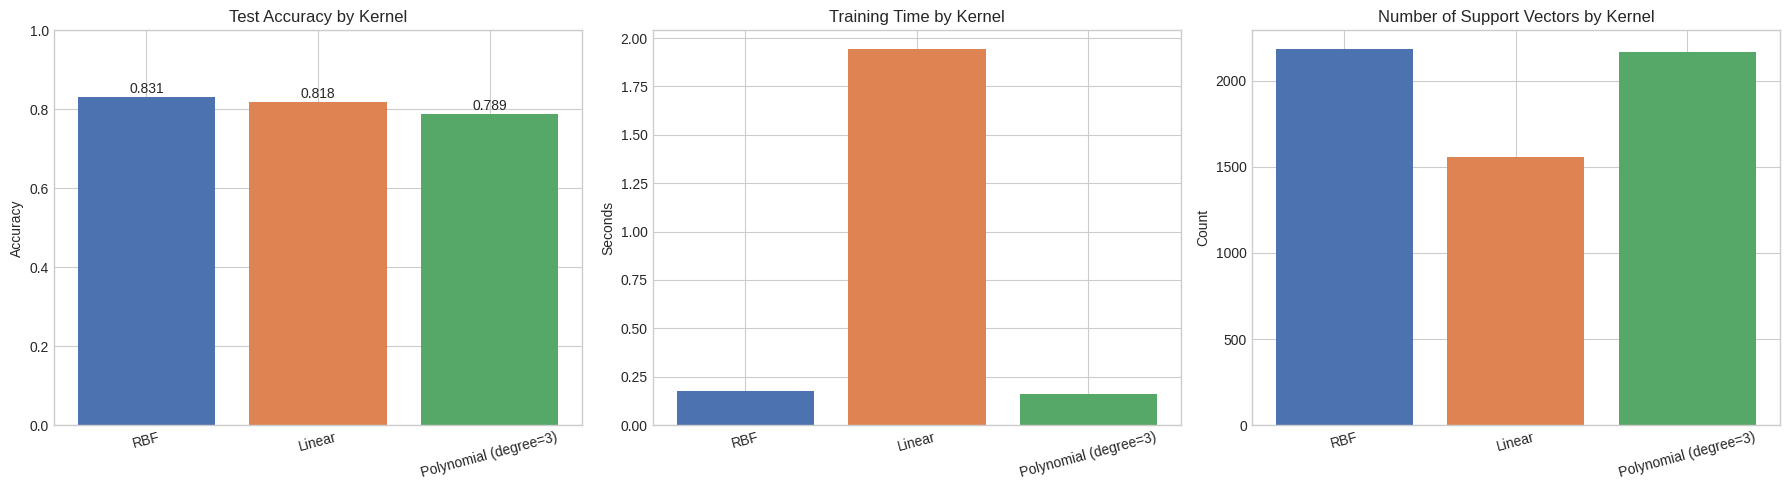

In [9]:
# Bar chart comparison: accuracy and training time
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(summary_df['Kernel'], summary_df['Accuracy'], color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('Test Accuracy by Kernel')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
for i, v in enumerate(summary_df['Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center')

axes[1].bar(summary_df['Kernel'], summary_df['Train Time (s)'], color=['#4C72B0', '#DD8452', '#55A868'])
axes[1].set_title('Training Time by Kernel')
axes[1].set_ylabel('Seconds')

axes[2].bar(summary_df['Kernel'], summary_df['Support Vectors'], color=['#4C72B0', '#DD8452', '#55A868'])
axes[2].set_title('Number of Support Vectors by Kernel')
axes[2].set_ylabel('Count')

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [10]:
# Detailed classification report for each kernel
for name in results:
    print(f'===== {name} Kernel =====')
    print(classification_report(y_test_sub, results[name]['y_pred'], target_names=class_names))

===== Linear Kernel =====
              precision    recall  f1-score   support

 T-shirt/top       0.74      0.84      0.79       100
     Trouser       0.97      0.93      0.95       100
    Pullover       0.71      0.64      0.67       100
       Dress       0.86      0.89      0.87       100
        Coat       0.71      0.75      0.73       100
      Sandal       0.87      0.88      0.88       100
       Shirt       0.63      0.57      0.60       100
     Sneaker       0.87      0.90      0.88       100
         Bag       0.94      0.89      0.91       100
  Ankle boot       0.90      0.89      0.89       100

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000

===== Polynomial (degree=3) Kernel =====
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.80      0.80       100
     Trouser       1.00      0.90      0.95       100
    Pullove

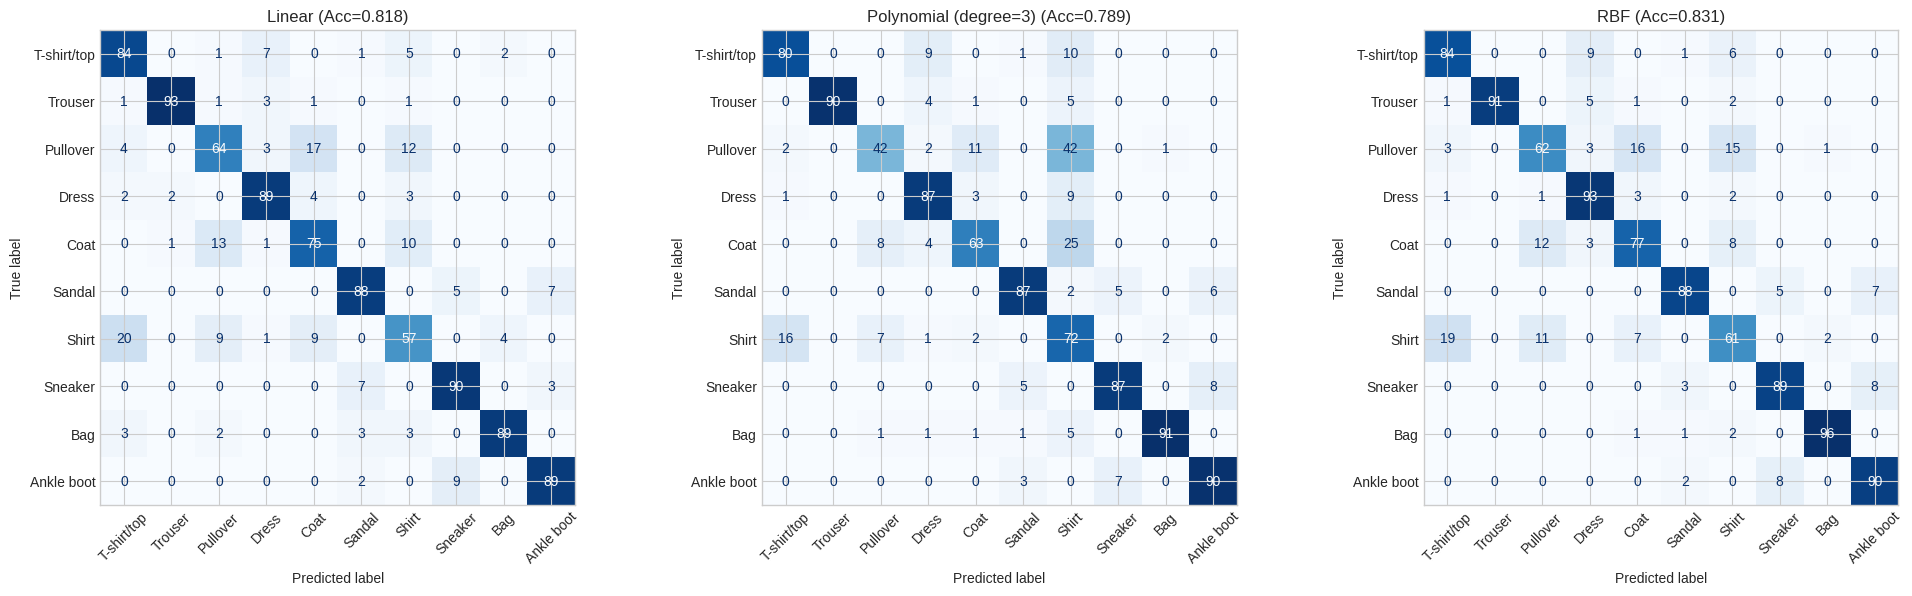

In [11]:
# Confusion matrices side-by-side for visual comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, name in zip(axes, results):
    cm = confusion_matrix(y_test_sub, results[name]['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(f'{name} (Acc={results[name]["accuracy"]:.3f})')

plt.tight_layout()
plt.show()

### Visualizing Decision Boundaries in 2D

To build intuition, we also project the data onto its first 2 principal components and visualize how each kernel separates 3 representative classes (T-shirt/top, Trouser, Sneaker).

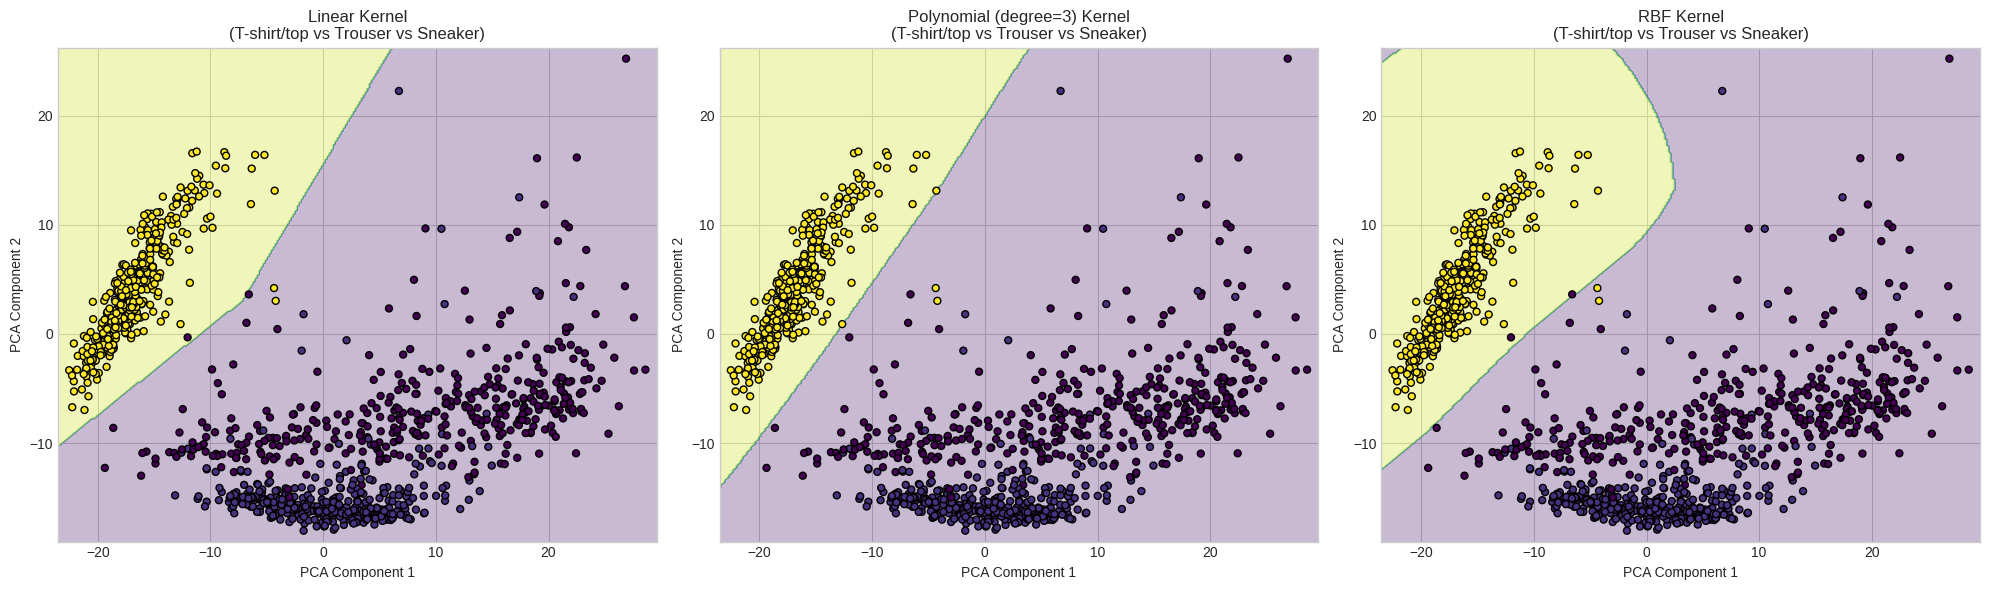

In [12]:
# Pick 3 visually distinct classes for a clean 2D boundary plot
classes_to_plot = [0, 1, 7]  # T-shirt/top, Trouser, Sneaker
mask_train = np.isin(y_train_sub, classes_to_plot)

X_vis = X_train_pca[mask_train][:, :2]  # first 2 PCA components only
y_vis = y_train_sub[mask_train]

vis_kernels = {
    'Linear': SVC(kernel='linear', C=1.0),
    'Polynomial (degree=3)': SVC(kernel='poly', degree=3, C=1.0, gamma='scale'),
    'RBF': SVC(kernel='rbf', C=1.0, gamma='scale')
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

for ax, (name, model) in zip(axes, vis_kernels.items()):
    model.fit(X_vis, y_vis)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    scatter = ax.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap='viridis',
                          edgecolors='k', s=25)
    ax.set_title(f'{name} Kernel\n(T-shirt/top vs Trouser vs Sneaker)')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')

plt.tight_layout()
plt.show()

## Task 4: Discussion — Strengths and Weaknesses of Each Kernel

| Kernel | How it works | Advantages | Disadvantages |
|---|---|---|---|
| **Linear** | Separates classes with a straight hyperplane: $K(x, x') = x \cdot x'$ | - Fastest to train and predict.<br>- Fewer hyperparameters to tune (just C).<br>- Works well when data is (approximately) linearly separable or when the number of features is large relative to samples.<br>- Easier to interpret — the weight vector directly shows feature importance. | - Cannot capture non-linear relationships between pixel intensities.<br>- Typically the lowest accuracy on complex image data like Fashion MNIST, since clothing categories are not linearly separable in raw/PCA pixel space. |
| **Polynomial** | Maps data into a higher-dimensional polynomial feature space: $K(x, x') = (\gamma\, x \cdot x' + r)^d$ | - Can model curved/non-linear decision boundaries.<br>- Degree $d$ gives flexible control over model complexity.<br>- Useful when there are meaningful interaction effects between features. | - Sensitive to the choice of degree, gamma, and coefficient — small changes can drastically change results.<br>- Prone to overfitting at high degrees and numerically unstable for large feature values.<br>- Slower to train than linear, and generally harder to tune than RBF. |
| **RBF (Gaussian)** | Measures similarity via a Gaussian function: $K(x, x') = \exp(-\gamma \lVert x - x' \rVert^2)$ | - Captures complex, non-linear decision boundaries very effectively.<br>- Usually achieves the highest accuracy on image data such as Fashion MNIST, since it can flexibly wrap around clusters of similar images.<br>- Only 2 hyperparameters to tune (C and gamma), and works well in practice as a default choice. | - Slower to train and predict than linear (especially as the number of support vectors grows).<br>- More prone to overfitting if gamma is too large (very tight, wiggly boundary) or underfitting if gamma is too small.<br>- Less interpretable — no direct way to read off feature importance. |

**Summary of what we typically observe on Fashion MNIST:**
- The **RBF kernel** usually achieves the **highest accuracy**, because clothing images (e.g., distinguishing a shirt from a pullover) require non-linear decision boundaries in pixel/PCA space.
- The **Linear kernel** is the **fastest** to train, but has the **lowest accuracy**, since it can only draw straight-line boundaries between classes.
- The **Polynomial kernel** sits in between in terms of accuracy, but is often the **most sensitive to hyperparameters** (degree, gamma, coef0), and can be **unstable** — either overfitting or underfitting depending on the chosen degree.
- In terms of **support vectors**, non-linear kernels (poly, RBF) tend to require **more support vectors** than the linear kernel to represent the more complex boundary, which increases prediction time.

**Practical takeaway:** For image classification tasks like Fashion MNIST, the RBF kernel is usually the best out-of-the-box choice when using classical SVMs (as opposed to deep learning), but it requires careful tuning of `C` and `gamma` (e.g., via grid search / cross-validation) to get the best trade-off between accuracy and training/prediction time. The Linear kernel remains attractive when speed and interpretability are more important than absolute accuracy, or when working with very high-dimensional/sparse feature representations.